# SHMS Reduced-Data MLP 校准验证（Notebook版）

本笔记本将 `train_reduced_mlp.py` 训练流程迁移到交互式 Notebook，并新增可视化：

- 全量训练（不做 training fraction 扫描）下的 RMSE/MAE
- 预测 vs 真值散点图（parity plot）
- 残差分布图
- 训练损失曲线

支持自动识别 ROOT 分支前缀 `ps*` 或 `hs*`。

In [29]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from datetime import datetime
from typing import Any
import math
import json

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import uproot
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print('Device:', DEVICE)

Device: mps


In [42]:
# ===== 配置区（按需修改） =====
ROOT_FILE = Path('../mc-single-arm/worksim/shms_nn_train_3gev15deg.root')  # 若从 SHMS_Calibration_NN 目录启动
if not ROOT_FILE.exists():
    # 若在 experiments/mlp_reduced_data_test 目录启动
    alt = Path('../../../mc-single-arm/worksim/shms_nn_train_3gev15deg.root')
    if alt.exists():
        ROOT_FILE = alt

INP_FILE = Path('../mc-single-arm/infiles/shms_nn_train_3gev15deg.inp')
if not INP_FILE.exists():
    alt_inp = Path('../../../mc-single-arm/infiles/shms_nn_train_3gev15deg.inp')
    if alt_inp.exists():
        INP_FILE = alt_inp

TREE_NAME = 'h10'
TARGET_MODE = 'core3'  # 'core3' | 'all' | 'delta-only'
FILTER_STOP_ID = True  # 仅保留 stop_id == 0 成功传输事件
MAX_EVENTS = 100_000
VAL_FRACTION = 0.20
EPOCHS = 40
BATCH_SIZE = 2048
LR = 1e-3
WEIGHT_DECAY = 1e-5
SEED = 42

# P0 默认从 .inp 自动解析；若想手动固定可改成具体数值（单位 GeV/c）
P0_OVERRIDE: float | None = None

# x_tar 使用确定性常数 0，避免注入随机噪声破坏监督映射
X_TAR_MODE = 'zero'  # 'zero' | 'random'
X_TAR_SIGMA = 0.1    # 仅在 X_TAR_MODE='random' 时生效

# 输出目录：兼容两种启动位置
OUTPUT_DIR = Path('outputs_notebook')
if Path.cwd().name != 'mlp_reduced_data_test':
    OUTPUT_DIR = Path('experiments/mlp_reduced_data_test/outputs_notebook')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT_FILE =', ROOT_FILE.resolve())
print('INP_FILE  =', INP_FILE.resolve() if INP_FILE.exists() else '(not found)')
print('OUTPUT_DIR =', OUTPUT_DIR.resolve())

ROOT_FILE = /Users/zhengxiaoyang/Desktop/AI_ML R-SIDIS/mc-single-arm/worksim/shms_nn_train_3gev15deg.root
INP_FILE  = /Users/zhengxiaoyang/Desktop/AI_ML R-SIDIS/mc-single-arm/infiles/shms_nn_train_3gev15deg.inp
OUTPUT_DIR = /Users/zhengxiaoyang/Desktop/AI_ML R-SIDIS/SHMS_Calibration_NN/experiments/mlp_reduced_data_test/outputs_notebook


In [46]:
def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)


def detect_prefix(branches: list[str]) -> str:
    for pref in ['ps', 'hs']:
        required = [f'{pref}xfp', f'{pref}yfp', f'{pref}xpfp', f'{pref}ypfp', f'{pref}deltai']
        if all(r in branches for r in required):
            return pref
    raise RuntimeError('Cannot detect branch prefix. Expected ps* or hs* branches.')


def infer_p0_from_inp(inp_file: Path) -> float | None:
    if not inp_file.exists():
        return None
    target_keywords = ('Spectrometer central momentum', 'Spectrometer momentum')
    for line in inp_file.read_text(encoding='utf-8', errors='ignore').splitlines():
        if any(k in line for k in target_keywords):
            # 从整行中提取第一个可解析浮点值（兼容是否有 '|' 注释分隔）
            for token in line.replace(',', ' ').split():
                try:
                    p0_mev = float(token)
                    return p0_mev / 1000.0
                except ValueError:
                    continue
    return None


@dataclass
class DataBundle:
    X: np.ndarray
    Y: np.ndarray
    feature_names: list[str]
    target_names: list[str]
    prefix: str
    n_all: int
    n_after_filter: int


def load_data(
    root_file: Path,
    tree_name: str,
    target_mode: str,
    p0: float,
    x_tar_mode: str,
    x_tar_sigma: float,
    max_events: int,
    seed: int,
    filter_stop_id: bool,
) -> DataBundle:
    rf: Any = uproot.open(root_file)
    tree = rf[tree_name]
    branches = list(tree.keys())

    pref = detect_prefix(branches)
    input_branches = [f'{pref}xfp', f'{pref}yfp', f'{pref}xpfp', f'{pref}ypfp']

    if target_mode == 'all':
        target_branches = [f'{pref}deltai', f'{pref}xptari', f'{pref}yptari', f'{pref}ztari']
        target_names = ['delta', 'xptar', 'yptar', 'ytar']
    elif target_mode == 'core3':
        target_branches = [f'{pref}deltai', f'{pref}xptari', f'{pref}yptari']
        target_names = ['delta', 'xptar', 'yptar']
    elif target_mode == 'delta-only':
        target_branches = [f'{pref}deltai']
        target_names = ['delta']
    else:
        raise ValueError("TARGET_MODE must be one of: 'core3', 'all', 'delta-only'")

    wanted = input_branches + target_branches + (['stop_id'] if filter_stop_id else [])
    arr = tree.arrays(wanted, library='np')
    rf.close()

    n_all = len(arr[input_branches[0]])
    n = min(n_all, max_events) if max_events is not None else n_all

    X_raw = np.column_stack([arr[b][:n].astype(np.float32) for b in input_branches])
    Y_raw = np.column_stack([arr[b][:n].astype(np.float32) for b in target_branches])

    mask = np.isfinite(X_raw).all(axis=1) & np.isfinite(Y_raw).all(axis=1)
    if filter_stop_id:
        mask &= (arr['stop_id'][:n] == 0)

    X_raw = X_raw[mask]
    Y_raw = Y_raw[mask]
    n_after_filter = int(mask.sum())

    if x_tar_mode == 'random':
        rng = np.random.default_rng(seed)
        x_tar = rng.normal(0.0, x_tar_sigma, size=(n_after_filter, 1)).astype(np.float32)
    elif x_tar_mode == 'zero':
        x_tar = np.zeros((n_after_filter, 1), dtype=np.float32)
    else:
        raise ValueError("X_TAR_MODE must be 'zero' or 'random'")

    p0_col = np.full((n_after_filter, 1), p0, dtype=np.float32)
    X = np.concatenate([X_raw, x_tar, p0_col], axis=1)

    return DataBundle(
        X=X,
        Y=Y_raw,
        feature_names=['x_fp', 'y_fp', 'xp_fp', 'yp_fp', 'x_tar', 'p0'],
        target_names=target_names,
        prefix=pref,
        n_all=n_all,
        n_after_filter=n_after_filter,
    )

In [32]:
class ResidualBlock(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.0):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.act = nn.SiLU()
        self.fc2 = nn.Linear(dim, dim)
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.fc1(x)
        h = self.act(h)
        h = self.drop(h)
        h = self.fc2(h)
        return self.act(x + h)


class ResidualMLP(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, hidden: int = 256, n_blocks: int = 4, dropout: float = 0.0):
        super().__init__()
        self.input = nn.Sequential(nn.Linear(in_dim, hidden), nn.SiLU())
        self.blocks = nn.Sequential(*[ResidualBlock(hidden, dropout=dropout) for _ in range(n_blocks)])
        self.head = nn.Linear(hidden, out_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.input(x)
        h = self.blocks(h)
        return self.head(h)


def run_training(
    X: np.ndarray,
    Y: np.ndarray,
    val_fraction: float,
    epochs: int,
    batch_size: int,
    lr: float,
    weight_decay: float,
    seed: int,
) -> dict[str, Any]:
    X_train, X_val, y_train, y_val = train_test_split(
        X, Y, test_size=val_fraction, random_state=seed, shuffle=True
    )

    n_train = len(X_train)

    sx = StandardScaler().fit(X_train)
    sy = StandardScaler().fit(y_train)

    X_train_s = sx.transform(X_train).astype(np.float32)
    X_val_s = sx.transform(X_val).astype(np.float32)
    y_train_s = sy.transform(y_train).astype(np.float32)
    y_val_s = sy.transform(y_val).astype(np.float32)

    model = ResidualMLP(in_dim=X.shape[1], out_dim=Y.shape[1], hidden=256, n_blocks=4, dropout=0.0).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.SmoothL1Loss()

    x_train_t = torch.from_numpy(X_train_s).to(DEVICE)
    y_train_t = torch.from_numpy(y_train_s).to(DEVICE)
    x_val_t = torch.from_numpy(X_val_s).to(DEVICE)
    y_val_t = torch.from_numpy(y_val_s).to(DEVICE)

    steps = math.ceil(len(x_train_t) / batch_size)
    train_loss_hist: list[float] = []
    val_loss_hist: list[float] = []

    for _ in range(epochs):
        model.train()
        perm = torch.randperm(len(x_train_t), device=DEVICE)
        epoch_loss = 0.0
        for s in range(steps):
            bidx = perm[s * batch_size : (s + 1) * batch_size]
            xb = x_train_t[bidx]
            yb = y_train_t[bidx]
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += float(loss.item())

        train_loss_hist.append(epoch_loss / max(steps, 1))

        model.eval()
        with torch.no_grad():
            pred_val_s_t = model(x_val_t)
            val_loss = loss_fn(pred_val_s_t, y_val_t).item()
        val_loss_hist.append(float(val_loss))

    model.eval()
    with torch.no_grad():
        pred_val_s = model(x_val_t).cpu().numpy()

    pred_val = sy.inverse_transform(pred_val_s)
    err = pred_val - y_val
    rmse = np.sqrt(np.mean(np.square(err), axis=0))
    mae = np.mean(np.abs(err), axis=0)

    return {
        'n_train': int(n_train),
        'n_val': int(len(X_val)),
        'rmse': rmse.tolist(),
        'mae': mae.tolist(),
        'train_loss_hist': train_loss_hist,
        'val_loss_hist': val_loss_hist,
        'y_true': y_val,
        'y_pred': pred_val,
    }

In [47]:
set_seed(SEED)

p0_from_inp = infer_p0_from_inp(INP_FILE)
P0 = P0_OVERRIDE if P0_OVERRIDE is not None else (p0_from_inp if p0_from_inp is not None else 1.4)
source_tag = 'from inp' if (p0_from_inp is not None and P0_OVERRIDE is None) else ('override' if P0_OVERRIDE is not None else 'default fallback')

bundle = load_data(
    root_file=ROOT_FILE,
    tree_name=TREE_NAME,
    target_mode=TARGET_MODE,
    p0=P0,
    x_tar_mode=X_TAR_MODE,
    x_tar_sigma=X_TAR_SIGMA,
    max_events=MAX_EVENTS,
    seed=SEED,
    filter_stop_id=FILTER_STOP_ID,
)

print(f'Prefix detected: {bundle.prefix}')
print(f'Events all={bundle.n_all}, after_filter={bundle.n_after_filter}')
print(f'X shape: {bundle.X.shape}, Y shape: {bundle.Y.shape}')
print('features:', bundle.feature_names)
print('targets :', bundle.target_names)
print('P0 used :', P0, 'GeV/c', f'({source_tag})')

Prefix detected: ps
Events all=100000, after_filter=33834
X shape: (33834, 6), Y shape: (33834, 3)
features: ['x_fp', 'y_fp', 'xp_fp', 'yp_fp', 'x_tar', 'p0']
targets : ['delta', 'xptar', 'yptar']
P0 used : 1.4 GeV/c (from inp)


In [34]:
result = run_training(
    X=bundle.X,
    Y=bundle.Y,
    val_fraction=VAL_FRACTION,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    seed=SEED,
)

print(f"n_train={result['n_train']}, n_val={result['n_val']}, rmse={np.round(result['rmse'], 6).tolist()}")

n_train=27067, n_val=6767, rmse=[0.217187, 0.001693, 0.001398]


In [35]:
# 汇总表（全量训练，已过滤 stop_id）
row = {'n_train': result['n_train'], 'n_val': result['n_val']}
for i, t in enumerate(bundle.target_names):
    row[f'rmse_{t}'] = result['rmse'][i]
    row[f'mae_{t}'] = result['mae'][i]

df_metrics = pd.DataFrame([row])
df_metrics

,n_train,n_val,rmse_delta,mae_delta,rmse_xptar,mae_xptar,rmse_yptar,mae_yptar
0,27067,6767,0.217187,0.164379,0.001693,0.001257,0.001398,0.001112


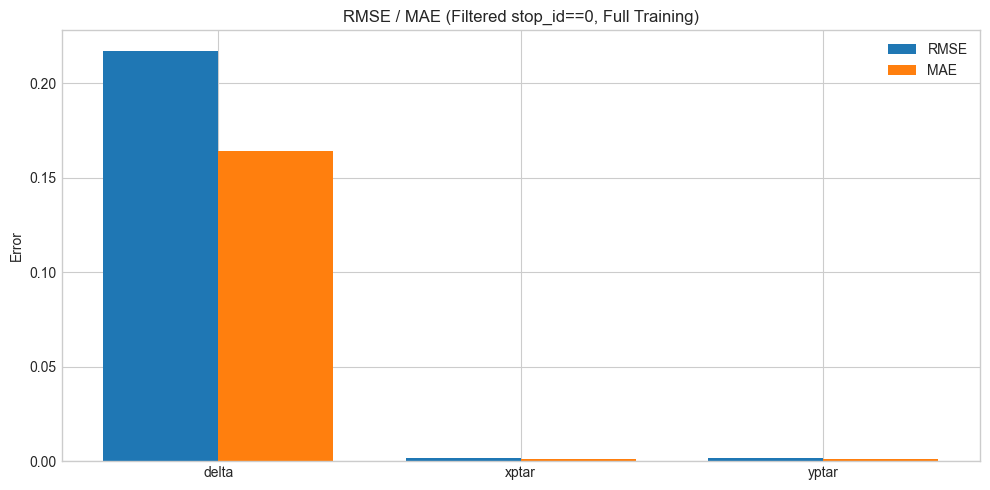

In [36]:
# 可视化1：全量训练下各目标 RMSE/MAE
targets = bundle.target_names
rmse_vals = [result['rmse'][i] for i in range(len(targets))]
mae_vals = [result['mae'][i] for i in range(len(targets))]

x = np.arange(len(targets))
w = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w / 2, rmse_vals, width=w, label='RMSE')
ax.bar(x + w / 2, mae_vals, width=w, label='MAE')
ax.set_xticks(x)
ax.set_xticklabels(targets)
ax.set_title('RMSE / MAE (Filtered stop_id==0, Full Training)')
ax.set_ylabel('Error')
ax.legend()
plt.tight_layout()
plt.show()

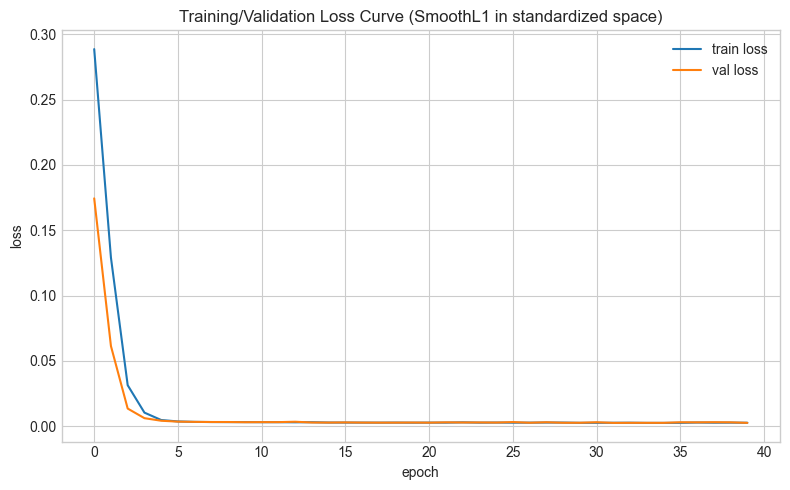

In [37]:
# 可视化2：训练/验证损失曲线
plt.figure(figsize=(8, 5))
plt.plot(result['train_loss_hist'], label='train loss')
plt.plot(result['val_loss_hist'], label='val loss')
plt.title('Training/Validation Loss Curve (SmoothL1 in standardized space)')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
print('n_train        =', result['n_train'])
print('n_val          =', result['n_val'])
print('rmse           =', np.round(result['rmse'], 6).tolist())
print('mae            =', np.round(result['mae'], 6).tolist())

n_train        = 27067
n_val          = 6767
rmse           = [0.217187, 0.001693, 0.001398]
mae            = [0.164379, 0.001257, 0.001112]


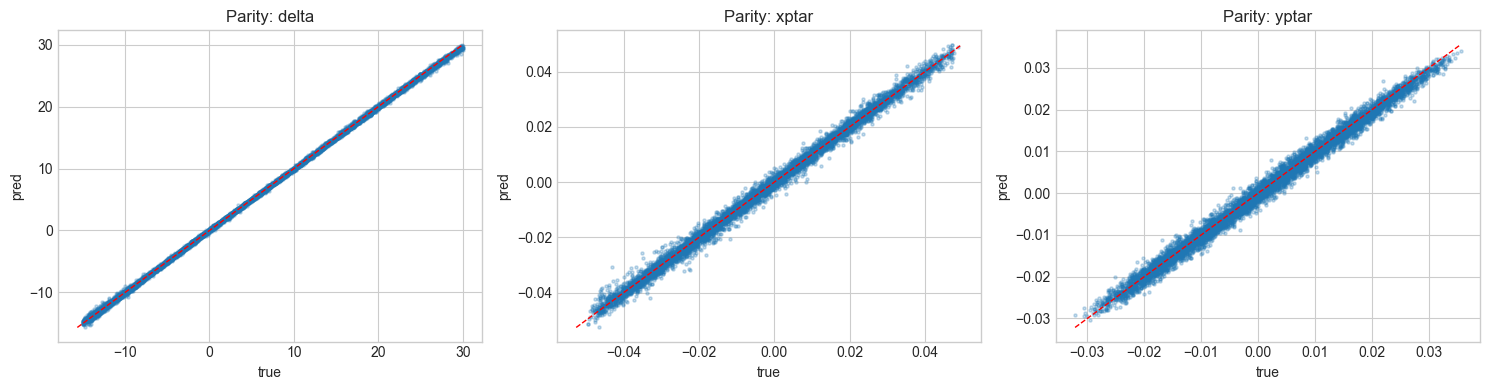

In [39]:
# 可视化3：预测 vs 真值（parity plot）
y_true = result['y_true']
y_pred = result['y_pred']
nt = y_true.shape[1]

fig, axes = plt.subplots(1, nt, figsize=(5 * nt, 4))
if nt == 1:
    axes = [axes]

for i, t in enumerate(bundle.target_names):
    ax = axes[i]
    yt = y_true[:, i]
    yp = y_pred[:, i]
    ax.scatter(yt, yp, s=5, alpha=0.25)
    lo = min(yt.min(), yp.min())
    hi = max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_title(f'Parity: {t}')
    ax.set_xlabel('true')
    ax.set_ylabel('pred')

plt.tight_layout()
plt.show()

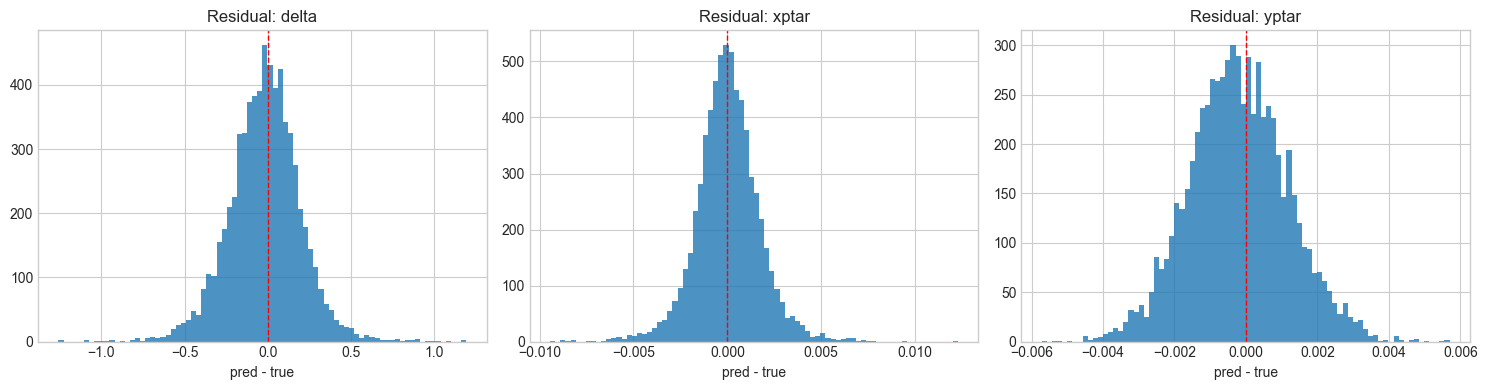

In [40]:
# 可视化4：残差分布
res = y_pred - y_true
nt = res.shape[1]
fig, axes = plt.subplots(1, nt, figsize=(5 * nt, 4))
if nt == 1:
    axes = [axes]

for i, t in enumerate(bundle.target_names):
    ax = axes[i]
    ax.hist(res[:, i], bins=80, alpha=0.8)
    ax.axvline(0.0, color='r', linestyle='--', linewidth=1)
    ax.set_title(f'Residual: {t}')
    ax.set_xlabel('pred - true')

plt.tight_layout()
plt.show()

In [41]:
# 保存结果（json + csv + png）
stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
mode = TARGET_MODE

metrics_json = OUTPUT_DIR / f'notebook_metrics_{mode}_{stamp}.json'
metrics_csv = OUTPUT_DIR / f'notebook_metrics_{mode}_{stamp}.csv'
plot_rmse = OUTPUT_DIR / f'notebook_rmse_mae_{mode}_{stamp}.png'
plot_parity = OUTPUT_DIR / f'notebook_parity_{mode}_{stamp}.png'
plot_resid = OUTPUT_DIR / f'notebook_residual_{mode}_{stamp}.png'

payload = {
    'root_file': str(ROOT_FILE.resolve()),
    'inp_file': str(INP_FILE.resolve()) if INP_FILE.exists() else None,
    'tree_name': TREE_NAME,
    'target_mode': TARGET_MODE,
    'filter_stop_id': FILTER_STOP_ID,
    'x_tar_mode': X_TAR_MODE,
    'feature_names': bundle.feature_names,
    'target_names': bundle.target_names,
    'max_events': MAX_EVENTS,
    'val_fraction': VAL_FRACTION,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'lr': LR,
    'weight_decay': WEIGHT_DECAY,
    'prefix': bundle.prefix,
    'p0_gev': P0,
    'events': {
        'all': bundle.n_all,
        'after_filter': bundle.n_after_filter,
    },
    'metrics': {
        'n_train': result['n_train'],
        'n_val': result['n_val'],
        'rmse': result['rmse'],
        'mae': result['mae'],
    },
}

with open(metrics_json, 'w', encoding='utf-8') as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

df_metrics.to_csv(metrics_csv, index=False)

# 重新绘图并保存（RMSE/MAE）
targets = bundle.target_names
rmse_vals = [result['rmse'][i] for i in range(len(targets))]
mae_vals = [result['mae'][i] for i in range(len(targets))]
x = np.arange(len(targets))
w = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w / 2, rmse_vals, width=w, label='RMSE')
ax.bar(x + w / 2, mae_vals, width=w, label='MAE')
ax.set_xticks(x)
ax.set_xticklabels(targets)
ax.set_title('RMSE / MAE (Filtered stop_id==0, Full Training)')
ax.set_ylabel('Error')
ax.legend()
plt.tight_layout()
plt.savefig(plot_rmse, dpi=150)
plt.close(fig)

# 保存 parity 图
y_true = result['y_true']
y_pred = result['y_pred']
nt = y_true.shape[1]
fig, axes = plt.subplots(1, nt, figsize=(5 * nt, 4))
if nt == 1:
    axes = [axes]
for i, t in enumerate(bundle.target_names):
    ax = axes[i]
    yt = y_true[:, i]
    yp = y_pred[:, i]
    ax.scatter(yt, yp, s=5, alpha=0.25)
    lo = min(yt.min(), yp.min())
    hi = max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_title(f'Parity: {t}')
    ax.set_xlabel('true')
    ax.set_ylabel('pred')
plt.tight_layout()
plt.savefig(plot_parity, dpi=150)
plt.close(fig)

# 保存 residual 图
res = y_pred - y_true
nt = res.shape[1]
fig, axes = plt.subplots(1, nt, figsize=(5 * nt, 4))
if nt == 1:
    axes = [axes]
for i, t in enumerate(bundle.target_names):
    ax = axes[i]
    ax.hist(res[:, i], bins=80, alpha=0.8)
    ax.axvline(0.0, color='r', linestyle='--', linewidth=1)
    ax.set_title(f'Residual: {t}')
    ax.set_xlabel('pred - true')
plt.tight_layout()
plt.savefig(plot_resid, dpi=150)
plt.close(fig)

print('Saved:')
print('-', metrics_json.resolve())
print('-', metrics_csv.resolve())
print('-', plot_rmse.resolve())
print('-', plot_parity.resolve())
print('-', plot_resid.resolve())

Saved:
- /Users/zhengxiaoyang/Desktop/AI_ML R-SIDIS/SHMS_Calibration_NN/experiments/mlp_reduced_data_test/experiments/mlp_reduced_data_test/outputs_notebook/notebook_metrics_core3_20260402_012623.json
- /Users/zhengxiaoyang/Desktop/AI_ML R-SIDIS/SHMS_Calibration_NN/experiments/mlp_reduced_data_test/experiments/mlp_reduced_data_test/outputs_notebook/notebook_metrics_core3_20260402_012623.csv
- /Users/zhengxiaoyang/Desktop/AI_ML R-SIDIS/SHMS_Calibration_NN/experiments/mlp_reduced_data_test/experiments/mlp_reduced_data_test/outputs_notebook/notebook_rmse_mae_core3_20260402_012623.png
- /Users/zhengxiaoyang/Desktop/AI_ML R-SIDIS/SHMS_Calibration_NN/experiments/mlp_reduced_data_test/experiments/mlp_reduced_data_test/outputs_notebook/notebook_parity_core3_20260402_012623.png
- /Users/zhengxiaoyang/Desktop/AI_ML R-SIDIS/SHMS_Calibration_NN/experiments/mlp_reduced_data_test/experiments/mlp_reduced_data_test/outputs_notebook/notebook_residual_core3_20260402_012623.png


## 建议解读

1. 先看 RMSE/MAE 柱状图，判断各目标量误差水平。
2. 再看 parity plot 是否贴近 $y=x$。
3. 看残差分布是否以 0 为中心、是否存在长尾。
4. 若 `delta-only` 更好，可改 `TARGET_MODE='delta-only'` 再跑同样流程。

In [27]:
import uproot
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

rf = uproot.open(str(ROOT_FILE))
tr = rf[TREE_NAME]
keys = list(tr.keys())
pref = "ps" if "psxfp" in keys else ("hs" if "hsxfp" in keys else None)
if pref is None:
    raise RuntimeError("Cannot detect ps*/hs* branch prefix")

branches = [
    f"{pref}xfp", f"{pref}yfp", f"{pref}xpfp", f"{pref}ypfp",
    f"{pref}deltai", f"{pref}xptari", f"{pref}yptari", f"{pref}ztari",
    "stop_id"
]
arr = tr.arrays(branches, library="np")

print("entries:", len(arr[branches[0]]))
vals, counts = np.unique(arr["stop_id"], return_counts=True)
print("stop_id counts:", dict(zip(vals.tolist(), counts.tolist())))

for b in branches[:-1]:
    x = arr[b].astype(float)
    q = np.quantile(x, [0, 0.001, 0.01, 0.5, 0.99, 0.999, 1.0])
    print(f"{b:10s} mean={x.mean():.5f} std={x.std():.5f} q={np.round(q, 5).tolist()}")

X = np.column_stack([
    arr[f"{pref}xfp"], arr[f"{pref}yfp"], arr[f"{pref}xpfp"], arr[f"{pref}ypfp"]
]).astype(float)
Y = np.column_stack([
    arr[f"{pref}deltai"], arr[f"{pref}xptari"], arr[f"{pref}yptari"], arr[f"{pref}ztari"]
]).astype(float)

for i, name in enumerate(["delta", "xptar", "yptar", "ytar"]):
    reg = LinearRegression().fit(X, Y[:, i])
    pred = reg.predict(X)
    print(f"linear R2 {name}: {r2_score(Y[:, i], pred):.6f}")

rf.close()

entries: 100000
stop_id counts: {0.0: 33834, 1.0: 5076, 2.0: 530, 3.0: 5589, 4.0: 8957, 5.0: 30120, 8.0: 5, 9.0: 5597, 10.0: 4073, 17.0: 4, 18.0: 527, 19.0: 28, 22.0: 375, 23.0: 79, 24.0: 1233, 25.0: 1445, 26.0: 1168, 27.0: 505, 28.0: 61, 33.0: 794}
psxfp      mean=5.17673 std=17.87635 q=[-36.63888, -35.85461, -32.59645, 6.61792, 35.89706, 37.31404, 37.87613]
psyfp      mean=-1.04363 std=9.32175 q=[-33.71676, -30.09821, -24.27834, -1.00205, 24.93201, 33.31752, 37.79087]
psxpfp     mean=0.01390 std=0.04113 q=[-0.08741, -0.08242, -0.07364, 0.0168, 0.08325, 0.08833, 0.09086]
psypfp     mean=-0.00103 std=0.01262 q=[-0.04811, -0.04285, -0.03348, -0.00225, 0.0359, 0.04532, 0.0507]
psdeltai   mean=7.50049 std=12.97474 q=[-14.99973, -14.95915, -14.54598, 7.4725, 29.54144, 29.95627, 29.99875]
psxptari   mean=-0.00001 std=0.02887 q=[-0.05, -0.0499, -0.04905, 9e-05, 0.04901, 0.0499, 0.05]
psyptari   mean=0.00002 std=0.03174 q=[-0.055, -0.05488, -0.0539, 8e-05, 0.05393, 0.05488, 0.055]
psztari    

In [28]:
# Quick ablation: successful transport only
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

mask_ok = arr["stop_id"] == 0
print("n_ok:", int(mask_ok.sum()), "fraction_ok:", float(mask_ok.mean()))

X_ok = X[mask_ok]
Y_ok = Y[mask_ok]
for i, name in enumerate(["delta", "xptar", "yptar", "ytar"]):
    reg = LinearRegression().fit(X_ok, Y_ok[:, i])
    pred = reg.predict(X_ok)
    print(f"linear R2 (stop_id==0) {name}: {r2_score(Y_ok[:, i], pred):.6f}")

# naive baseline RMSE (predict mean)
for i, name in enumerate(["delta", "xptar", "yptar", "ytar"]):
    y = Y_ok[:, i]
    rmse_mean = np.sqrt(np.mean((y - y.mean())**2))
    print(f"baseline RMSE mean-predictor {name}: {rmse_mean:.6f}")

n_ok: 33834 fraction_ok: 0.33834
linear R2 (stop_id==0) delta: 0.943596
linear R2 (stop_id==0) xptar: 0.888303
linear R2 (stop_id==0) yptar: 0.986478
linear R2 (stop_id==0) ytar: 0.000452
baseline RMSE mean-predictor delta: 12.333355
baseline RMSE mean-predictor xptar: 0.023196
baseline RMSE mean-predictor yptar: 0.014514
baseline RMSE mean-predictor ytar: 0.575121
